# HW06

Датасет: `S06-hw-dataset-02.csv`.

В ноутбуке:
- делается базовый EDA и проверка баланса классов;
- воспроизводится train/test protocol;
- запускается полный ML-эксперимент с baseline-моделями и ансамблями;
- отображаются финальные артефакты: метрики, ROC-кривые, confusion matrix и permutation importance.


In [1]:
from io import StringIO
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

import hw06_pipeline

ROOT = Path.cwd()
ARTIFACTS = ROOT / 'artifacts'
FIGURES = ARTIFACTS / 'figures'
DATA_PATH = hw06_pipeline.ensure_dataset()


In [2]:
df = hw06_pipeline.load_dataset()
X, y = hw06_pipeline.prepare_xy(df)

print('Shape:', df.shape)
print('Target share:')
display(y.value_counts(normalize=True).rename('share').to_frame())
display(df.head())
display(df.describe().T.head(10))


Shape: (18000, 39)
Target share:


,share
target,
0,0.737389
1,0.262611


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


,count,mean,std,min,25%,50%,75%,max
id,18000.0,9000.500000,5196.296758,1.000000,4500.750000,9000.500000,13500.250000,18000.000000
f01,18000.0,-0.418555,2.178005,-10.014698,-1.866134,-0.465100,0.966393,9.589975
f02,18000.0,0.614251,3.926778,-15.510323,-2.048192,0.600291,3.229850,15.417329
f03,18000.0,0.004559,1.000134,-4.031762,-0.673127,0.003581,0.671390,3.817025
f04,18000.0,0.059000,5.713672,-23.663256,-3.544964,0.072826,3.689490,26.815691
f05,18000.0,0.405086,2.497581,-12.289308,-1.153000,0.485625,2.075739,10.665184
f06,18000.0,0.012123,0.987226,-3.741536,-0.653090,0.018765,0.689304,3.528280
f07,18000.0,-0.283473,2.193891,-9.591425,-1.743214,-0.251263,1.195481,7.794627
f08,18000.0,-0.266880,2.081431,-8.293319,-1.688121,-0.302463,1.109589,8.892834
f09,18000.0,0.255107,2.225776,-13.655742,-1.177480,0.350739,1.764113,8.699629


In [3]:
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())
print('Missing values (top 10):')
display(df.isna().sum().sort_values(ascending=False).head(10).rename('missing_count').to_frame())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

,missing_count
id,0
f01,0
f02,0
f03,0
f04,0
f05,0
f06,0
f07,0
f08,0
f09,0


In [4]:
X_train, X_test, y_train, y_test = hw06_pipeline.make_split(X, y)
class_balance = pd.DataFrame({
    'split': ['train', 'train', 'test', 'test'],
    'target': [0, 1, 0, 1],
    'share': [
        (y_train == 0).mean(),
        (y_train == 1).mean(),
        (y_test == 0).mean(),
        (y_test == 1).mean(),
    ],
})
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
display(class_balance)


Train shape: (14400, 37) Test shape: (3600, 37)


,split,target,share
0,train,0,0.737361
1,train,1,0.262639
2,test,0,0.737500
3,test,1,0.262500


In [5]:
summary = hw06_pipeline.run_homework(force=True)
metrics_table = summary['metrics_table'].round(4)
display(metrics_table)
summary['search_summaries']


KeyboardInterrupt: 

In [6]:
display(summary['importance'].round(4))
display(summary['stability'].round(4))


,feature,importance_mean,importance_std
0,f16,0.0753,0.0039
1,f01,0.0292,0.0022
2,f07,0.0210,0.0021
3,f08,0.0198,0.0016
4,f30,0.0145,0.0013
5,f19,0.0130,0.0014
6,f23,0.0127,0.0020
7,f15,0.0096,0.0009
8,f34,0.0093,0.0007
9,f05,0.0091,0.0011


,seed,accuracy,f1,roc_auc
0,7,0.9064,0.8058,0.9297
1,13,0.9047,0.8000,0.9252
2,21,0.9058,0.8000,0.9305
3,42,0.9033,0.7974,0.9307
4,77,0.9039,0.7967,0.9330


roc_curves.png


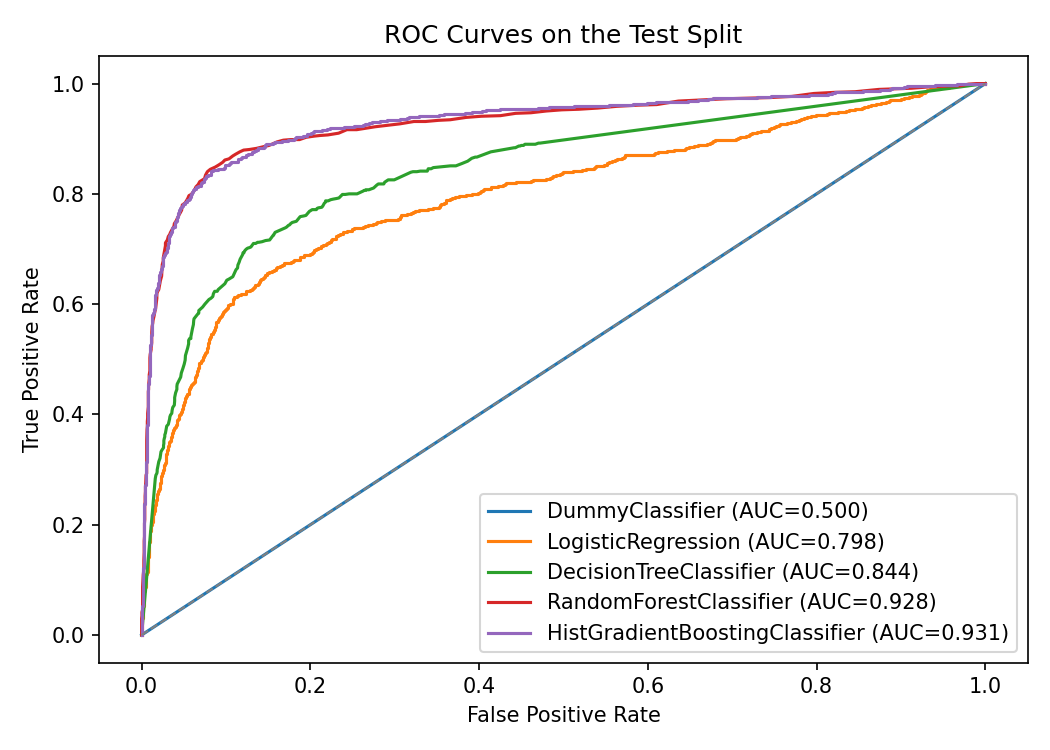

confusion_matrix.png


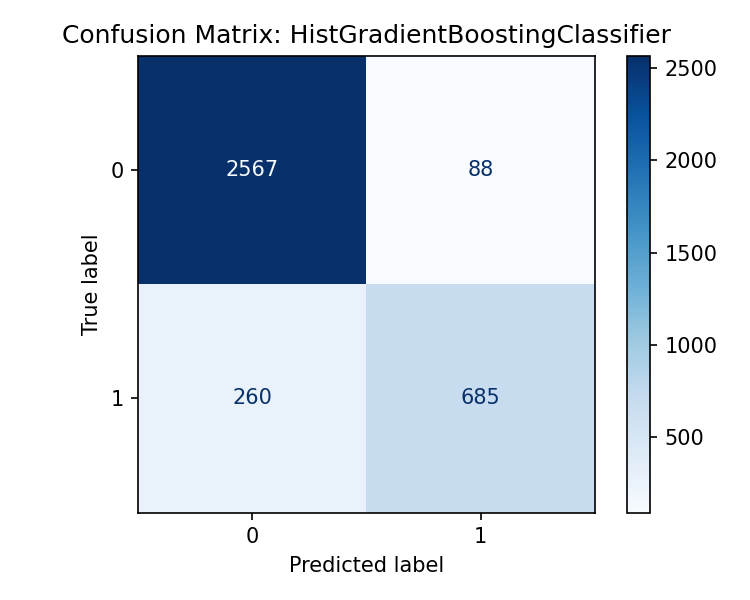

permutation_importance.png


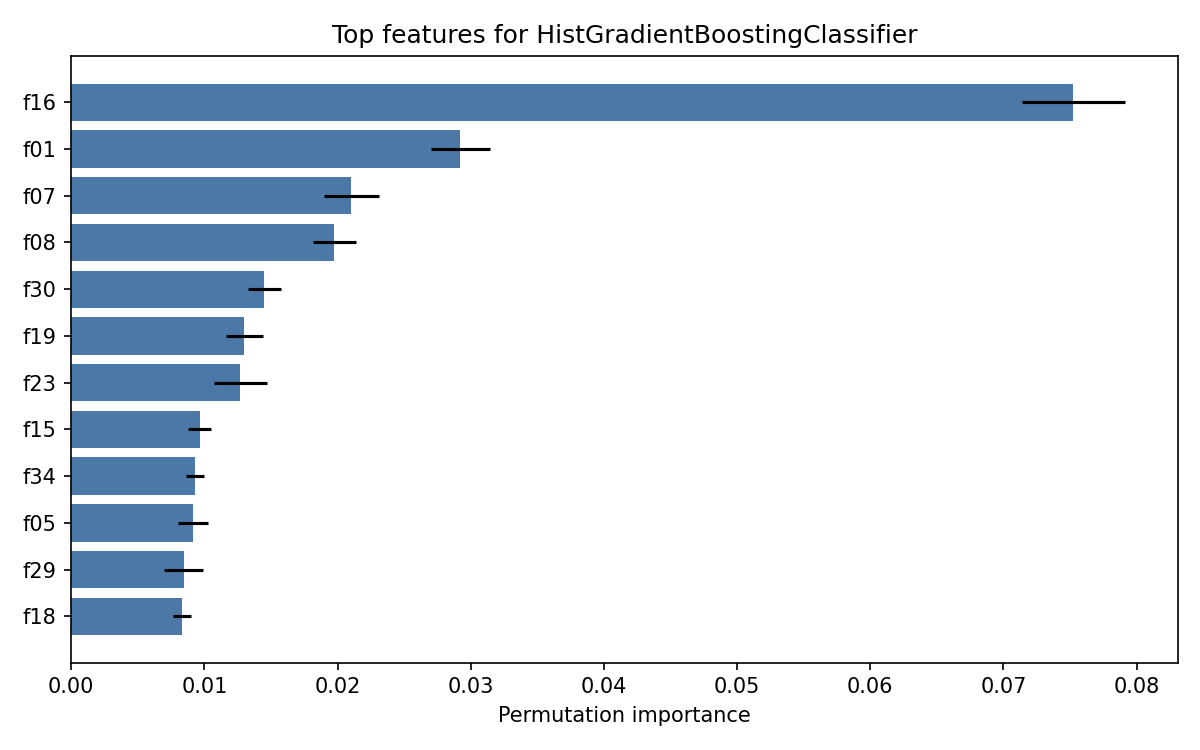

stability_across_seeds.png


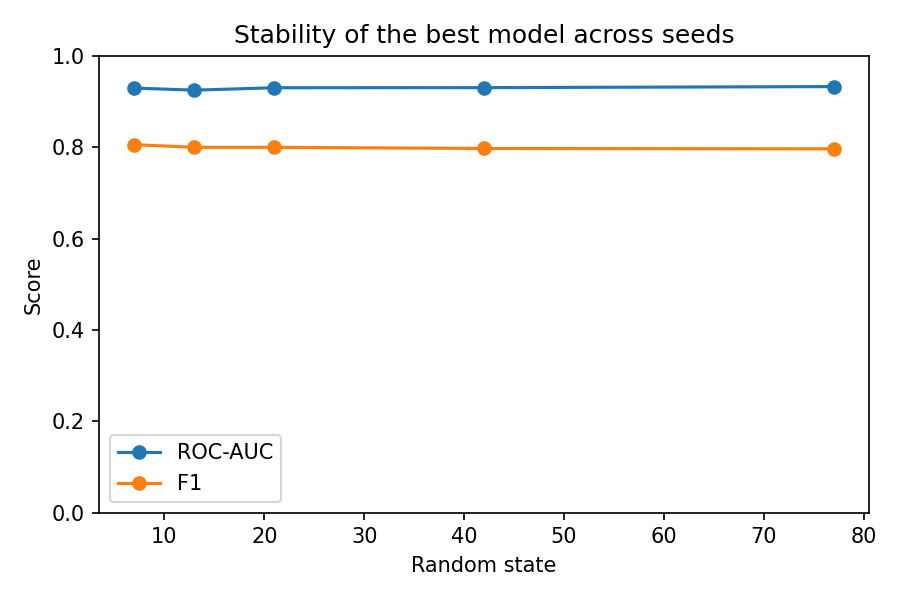

In [6]:
for image_name in ['roc_curves.png', 'confusion_matrix.png', 'permutation_importance.png', 'stability_across_seeds.png']:
    print(image_name)
    display(Image(filename=str(FIGURES / image_name)))


## Итог

Лучшей моделью стала `HistGradientBoostingClassifier`: она заметно обошла логистическую регрессию и одиночное дерево, а также показала стабильные метрики на нескольких значениях `random_state`. Все обязательные артефакты сохранены в `artifacts/`, а краткий вывод вынесен в `report.md`.
